In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_step1.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

In [4]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [5]:
df.drop('company', axis=1, inplace=True)

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df['agent'] = df['agent'].fillna(df['agent'].median())

In [8]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

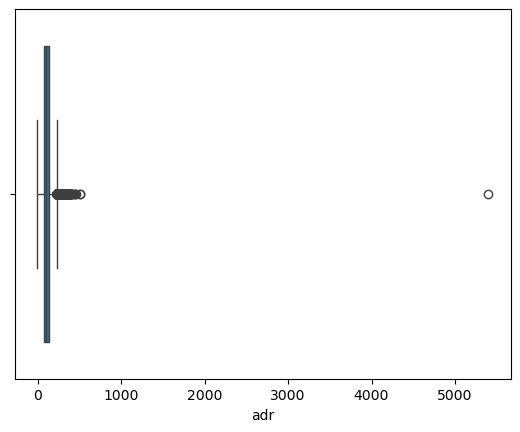

In [9]:
sns.boxplot(x=df['adr'])
plt.show()

In [10]:
df = df[df['adr'] < 500]

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87389.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000,87393.000000
mean,0.274896,79.893699,2016.210303,26.838557,15.815523,1.005298,2.625451,1.875802,0.138644,0.010825,0.039065,0.030414,0.183985,0.271601,82.958589,0.749591,106.267458,0.084217,0.698591
std,0.446464,86.052830,0.686096,13.674699,8.835213,1.031922,2.053597,0.626504,0.455888,0.113598,0.193751,0.369152,1.731921,0.727252,108.606444,10.015902,51.983328,0.281521,0.831950
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,451.500000,8.000000,5.000000


In [12]:
df.to_csv('cleaned_step2.csv', index=False)

In [16]:
plt.style.use('default')
sns.set_palette("Set2")
import warnings
warnings.filterwarnings('ignore')

In [17]:
#Basic Data Inspection
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()
print("\nMissing Values:")
df.isnull().sum().sort_values(ascending=False)

Dataset Shape: (87393, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 87393 entries, 0 to 87395
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87393 non-null  object 
 1   is_canceled                     87393 non-null  int64  
 2   lead_time                       87393 non-null  int64  
 3   arrival_date_year               87393 non-null  int64  
 4   arrival_date_month              87393 non-null  object 
 5   arrival_date_week_number        87393 non-null  int64  
 6   arrival_date_day_of_month       87393 non-null  int64  
 7   stays_in_weekend_nights         87393 non-null  int64  
 8   stays_in_week_nights            87393 non-null  int64  
 9   adults                          87393 non-null  int64  
 10  children                        87389 non-null  float64
 11  babies                          87393 non-null  i

children                          4
is_canceled                       0
hotel                             0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
lead_time                         0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [18]:
# Total stay duration
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Handle missing values in children
df['children'] = df['children'].fillna(0)

# Total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

df[['total_stay', 'total_guests']].head()

,total_stay,total_guests
0,0,2.0
1,0,2.0
2,1,1.0
3,1,1.0
4,2,2.0


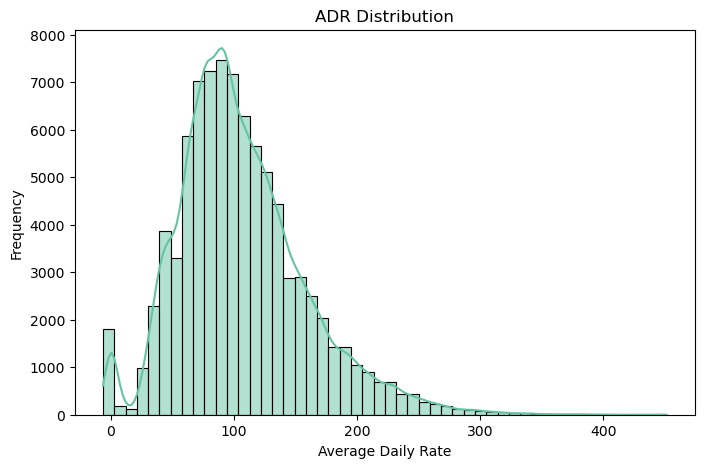

In [20]:
#ADR Distribution Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['adr'], bins=50, kde=True)
plt.title('ADR Distribution')
plt.xlabel('Average Daily Rate')
plt.ylabel('Frequency')
plt.show()

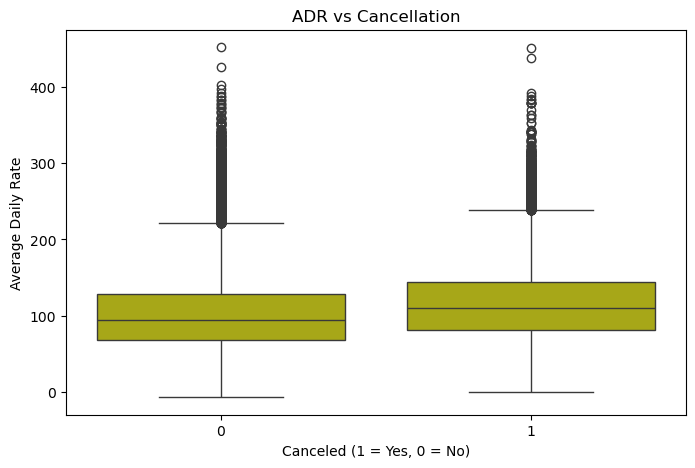

In [29]:
#ADR vs Cancellation Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled', y='adr', data=df,color = 'y')
plt.title('ADR vs Cancellation')
plt.xlabel('Canceled (1 = Yes, 0 = No)')
plt.ylabel('Average Daily Rate')
plt.show()

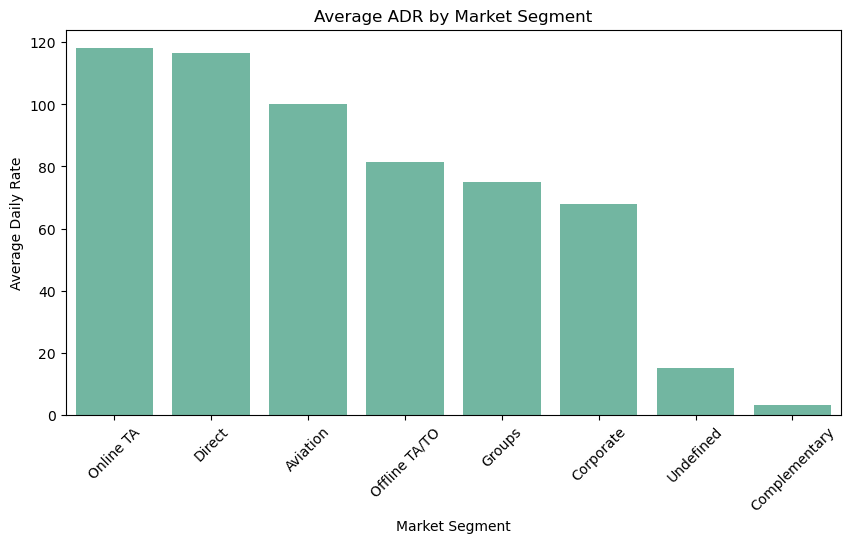

In [33]:
# Calculate average ADR by market segment
market_adr = df.groupby('market_segment')['adr'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(
    x=market_adr.index,
    y=market_adr.values
)
plt.xticks(rotation=45)
plt.title('Average ADR by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Average Daily Rate')
plt.show()

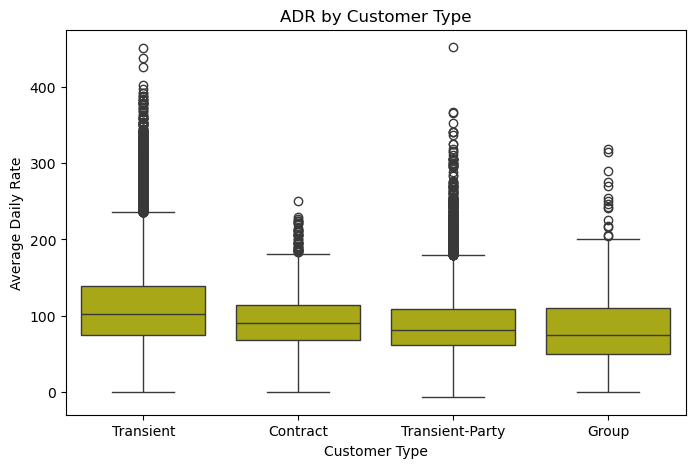

In [32]:
#ADR by Customer Type
plt.figure(figsize=(8,5))
sns.boxplot(x='customer_type', y='adr', data=df,color = 'y')
plt.title('ADR by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Daily Rate')
plt.show()